# Exploratory Data Analysis — Smart Attendance System (Biometric IoT Data)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/cleaned_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = pd.to_datetime(df['date']).dt.date

attendance = df[df['event_type'] == 'Check-In'].copy()
attendance.shape

(4148, 25)

## 1. Attendance trend — single department deep-dive

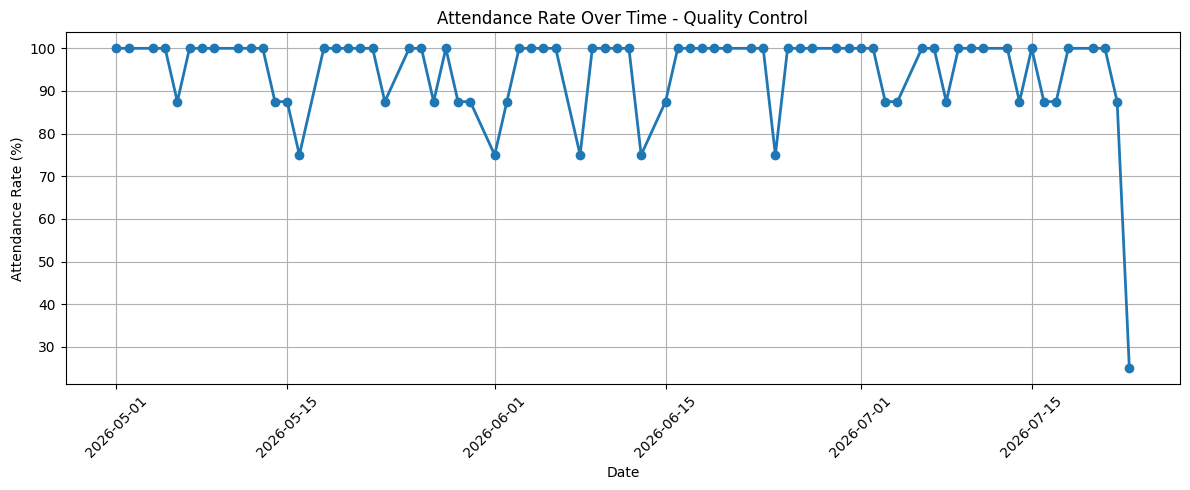

Average Attendance Rate (Quality Control): 94.44 %
Highest Attendance (Quality Control): 100.0 %
Lowest Attendance (Quality Control): 25.0 %


In [2]:
sample_department = "Quality Control"
dept = attendance[attendance['department'] == sample_department]

daily_present = dept.groupby('date')['employee_id'].nunique()
total_employees = dept['employee_id'].nunique()
attendance_rate = (daily_present / total_employees) * 100

plt.figure(figsize=(12,5))
plt.plot(attendance_rate.index, attendance_rate.values, marker='o', linewidth=2)
plt.title(f"Attendance Rate Over Time - {sample_department}")
plt.xlabel("Date")
plt.ylabel("Attendance Rate (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Average Attendance Rate ({sample_department}):", round(attendance_rate.mean(),2), "%")
print(f"Highest Attendance ({sample_department}):", round(attendance_rate.max(),2), "%")
print(f"Lowest Attendance ({sample_department}):", round(attendance_rate.min(),2), "%")

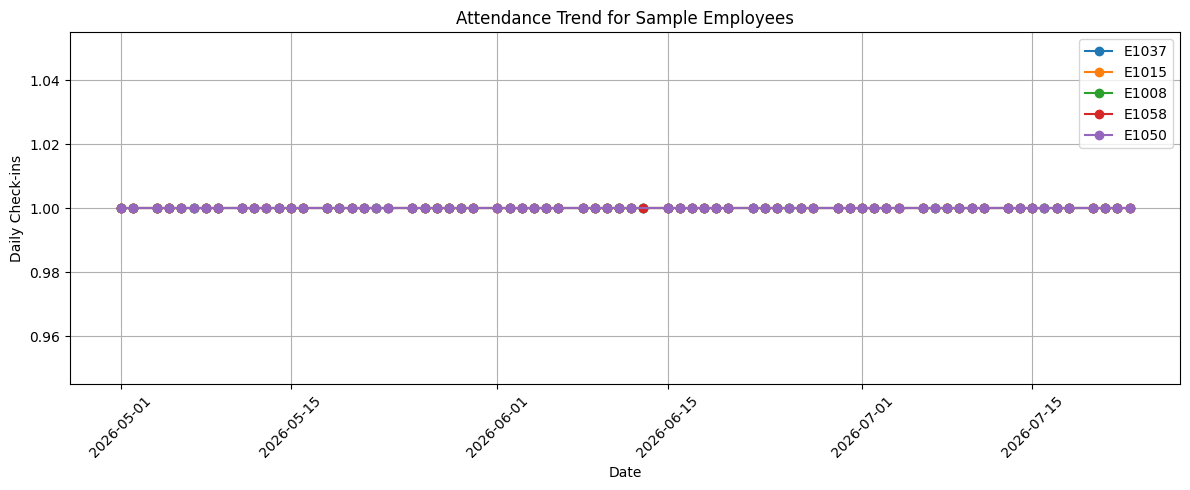

In [3]:
sample_employees = attendance['employee_id'].unique()[:5]

plt.figure(figsize=(12,5))
for emp in sample_employees:
    emp_data = attendance[attendance['employee_id'] == emp]
    daily = emp_data.groupby('date').size()
    plt.plot(daily.index, daily.values, marker='o', label=emp)

plt.title("Attendance Trend for Sample Employees")
plt.xlabel("Date")
plt.ylabel("Daily Check-ins")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Chronic absenteeism (org-wide)

In [4]:
working_days = attendance['date'].nunique()
employee_days = attendance.groupby('employee_id')['date'].nunique()

summary = pd.DataFrame()
summary['Days_Present'] = employee_days
summary['Attendance_Rate'] = (summary['Days_Present'] / working_days) * 100
summary['Days_Absent'] = working_days - summary['Days_Present']
summary['Chronic_Absentee'] = summary['Attendance_Rate'] < 80
summary = summary.sort_values(by='Attendance_Rate')

print(f"Total working days in dataset: {working_days}")
summary.head(10)

Total working days in dataset: 84


,Days_Present,Attendance_Rate,Days_Absent,Chronic_Absentee
employee_id,,,,
E1044,65,77.380952,19,True
E1028,66,78.571429,18,True
E1053,66,78.571429,18,True
E1060,66,78.571429,18,True
E1030,67,79.761905,17,True
E1016,67,79.761905,17,True
E1024,67,79.761905,17,True
E1031,67,79.761905,17,True
E1058,67,79.761905,17,True


In [5]:
chronic = summary[summary['Chronic_Absentee']]
print(f"{len(chronic)} employees below the 80% attendance threshold")
chronic

14 employees below the 80% attendance threshold


,Days_Present,Attendance_Rate,Days_Absent,Chronic_Absentee
employee_id,,,,
E1044,65,77.380952,19,True
E1028,66,78.571429,18,True
E1053,66,78.571429,18,True
E1060,66,78.571429,18,True
E1030,67,79.761905,17,True
E1016,67,79.761905,17,True
E1024,67,79.761905,17,True
E1031,67,79.761905,17,True
E1058,67,79.761905,17,True


## 3. Department & shift-wise patterns

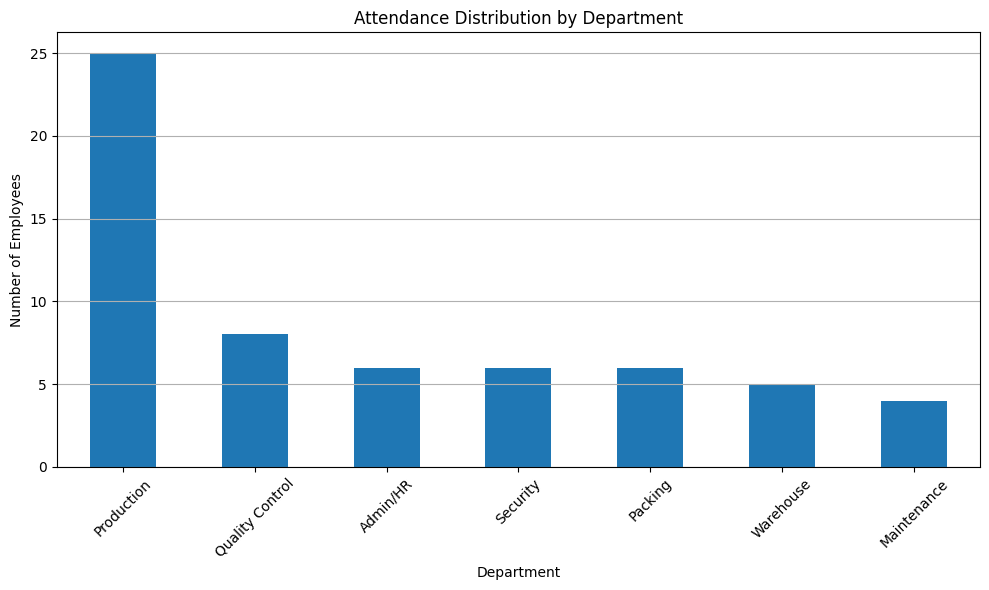

In [6]:
dept_attendance = attendance.groupby('department')['employee_id'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10,6))
dept_attendance.plot(kind='bar')
plt.title("Attendance Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

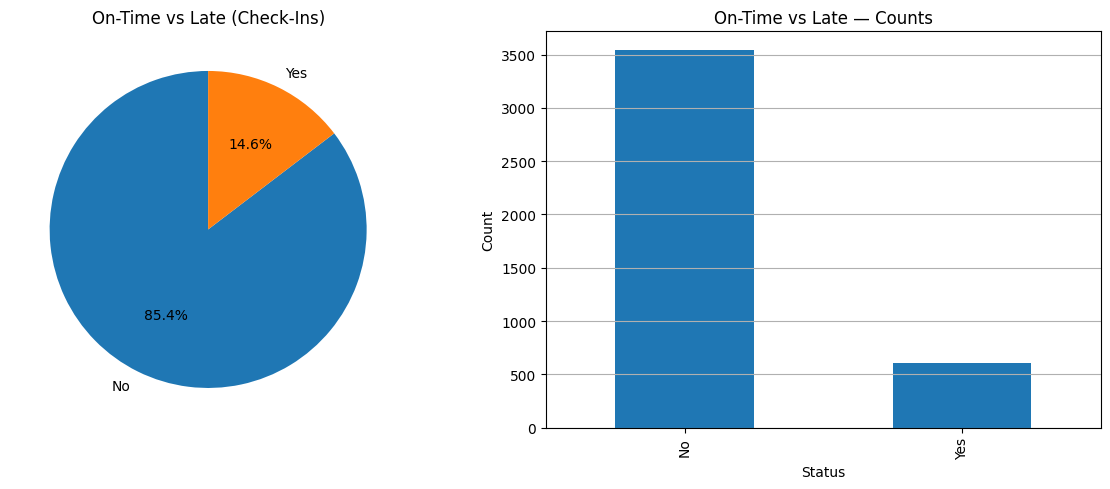

In [7]:
late_counts = attendance['is_late'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].pie(late_counts, labels=late_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("On-Time vs Late (Check-Ins)")

late_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title("On-Time vs Late — Counts")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Count")
axes[1].grid(axis='y')
plt.tight_layout()
plt.show()

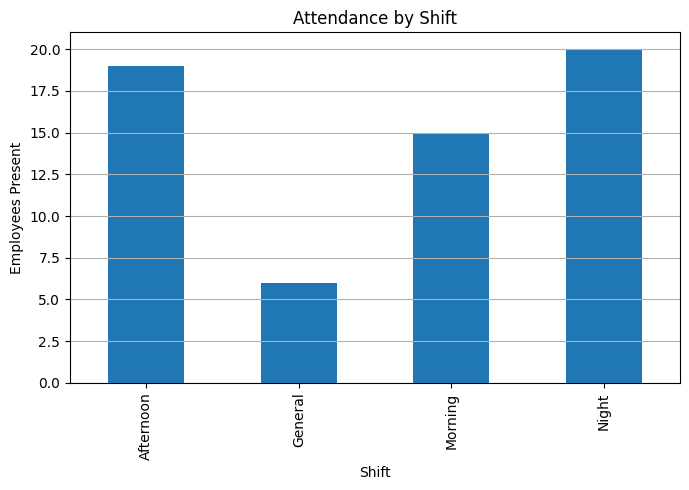

In [8]:
shift_attendance = attendance.groupby('shift')['employee_id'].nunique()

plt.figure(figsize=(7,5))
shift_attendance.plot(kind='bar')
plt.title("Attendance by Shift")
plt.xlabel("Shift")
plt.ylabel("Employees Present")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## 4. Session-level summary (all event types)

In [9]:
total_sessions = len(df)
unique_employees = df.loc[df['employee_id'] != 'UNVERIFIED', 'employee_id'].nunique()

print("="*40)
print("SESSION SUMMARY")
print("="*40)
print(f"Total Sessions          : {total_sessions}")
print(f"Unique Employees        : {unique_employees}")
print()
print("Breakdown by event type:")
print(df['event_type'].value_counts())
print()
checkins = df[df['event_type'] == 'Check-In']
print(f"Late Arrivals (of Check-Ins)   : {(checkins['is_late']=='Yes').sum()} / {len(checkins)}")
checkouts = df[df['event_type'] == 'Check-Out']
print(f"Early Exits (of Check-Outs)    : {(checkouts['is_early_exit']=='Yes').sum()} / {len(checkouts)}")
print("="*40)

SESSION SUMMARY
Total Sessions          : 10000
Unique Employees        : 82

Breakdown by event type:
event_type
Check-In                4148
Check-Out               4063
Check-In/Out Attempt    1623
Unauthorized Attempt     134
Enrollment                32
Name: count, dtype: int64

Late Arrivals (of Check-Ins)   : 607 / 4148
Early Exits (of Check-Outs)    : 352 / 4063


In [10]:
print(df['device_health_score'].describe())
print()
print(df['authentication_time_ms'].describe())

count    10000.000000
mean        85.543790
std          5.891898
min         70.100000
25%         80.900000
50%         85.600000
75%         90.500000
max         99.300000
Name: device_health_score, dtype: float64

count    10000.000000
mean       375.818580
std        105.063912
min        150.000000
25%        313.475000
50%        354.850000
75%        406.400000
max       1354.800000
Name: authentication_time_ms, dtype: float64


## 5. Fingerprint / biometric reliability (new)

This is the section that matters most for a *biometric* attendance system — how reliable is the sensor itself?

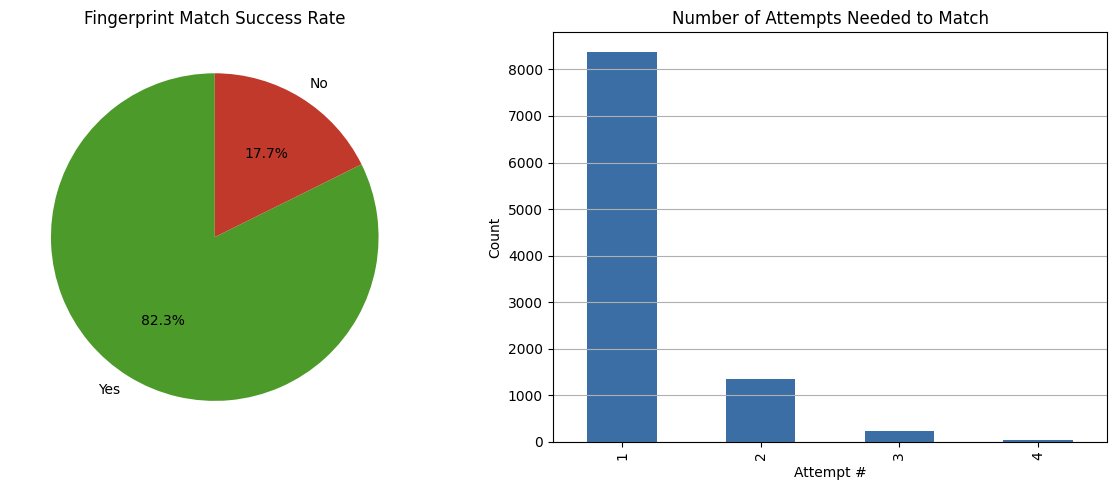

Overall match success rate: 82.33%
Sessions needing 2+ attempts: 1623 (16.2%)


In [11]:
match_counts = df['fingerprint_match'].value_counts()
match_rate = match_counts.get('Yes', 0) / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].pie(match_counts, labels=match_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4C9A2A','#C0392B'])
axes[0].set_title("Fingerprint Match Success Rate")

df['attempt_number'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#3B6EA5')
axes[1].set_title("Number of Attempts Needed to Match")
axes[1].set_xlabel("Attempt #")
axes[1].set_ylabel("Count")
axes[1].grid(axis='y')
plt.tight_layout()
plt.show()

print(f"Overall match success rate: {match_rate:.2f}%")
print(f"Sessions needing 2+ attempts: {(df['attempt_number']>1).sum()} ({(df['attempt_number']>1).mean()*100:.1f}%)")

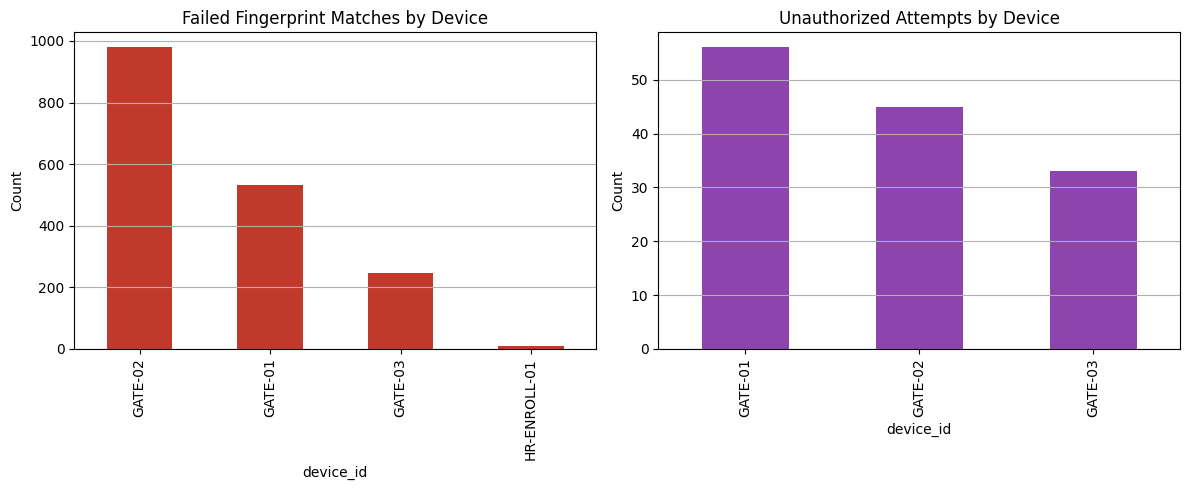

In [12]:
# Where do failed matches / unauthorized attempts cluster by device?
fail_by_device = df[df['fingerprint_match']=='No'].groupby('device_id').size().sort_values(ascending=False)
unauth_by_device = df[df['event_type']=='Unauthorized Attempt'].groupby('device_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
fail_by_device.plot(kind='bar', ax=axes[0], color='#C0392B')
axes[0].set_title("Failed Fingerprint Matches by Device")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y')

unauth_by_device.plot(kind='bar', ax=axes[1], color='#8E44AD')
axes[1].set_title("Unauthorized Attempts by Device")
axes[1].set_ylabel("Count")
axes[1].grid(axis='y')
plt.tight_layout()
plt.show()

## 6. Device / IoT hardware health (new)

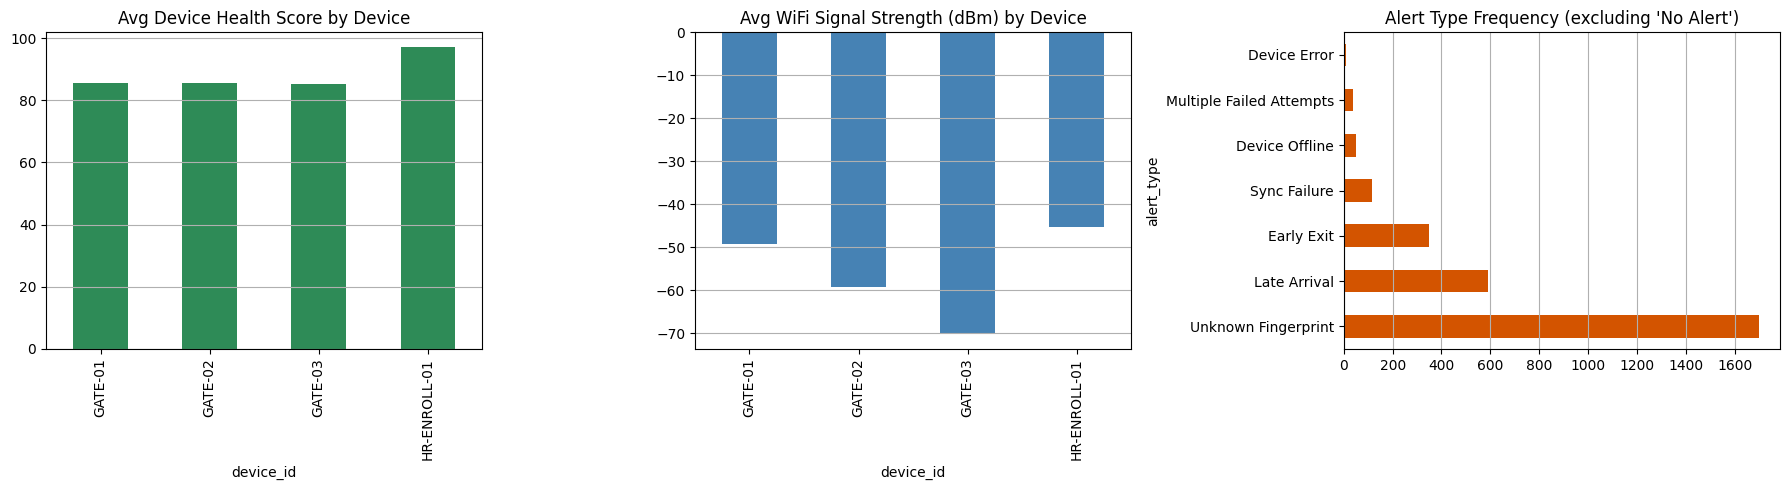

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

df.groupby('device_id')['device_health_score'].mean().plot(kind='bar', ax=axes[0], color='#2E8B57')
axes[0].set_title("Avg Device Health Score by Device")
axes[0].grid(axis='y')

df.groupby('device_id')['wifi_rssi_dbm'].mean().plot(kind='bar', ax=axes[1], color='#4682B4')
axes[1].set_title("Avg WiFi Signal Strength (dBm) by Device")
axes[1].grid(axis='y')

df['alert_type'].value_counts().drop('No Alert', errors='ignore').plot(kind='barh', ax=axes[2], color='#D35400')
axes[2].set_title("Alert Type Frequency (excluding 'No Alert')")
axes[2].grid(axis='x')

plt.tight_layout()
plt.show()

In [14]:
print("Device status breakdown:")
print(df['device_status'].value_counts())
print()
print("Database sync status breakdown:")
print(df['database_sync_status'].value_counts())

Device status breakdown:
device_status
ONLINE     9942
OFFLINE      50
ERROR         8
Name: count, dtype: int64

Database sync status breakdown:
database_sync_status
SYNCED    9825
FAILED     175
Name: count, dtype: int64


## 7. Peak check-in hours (new)

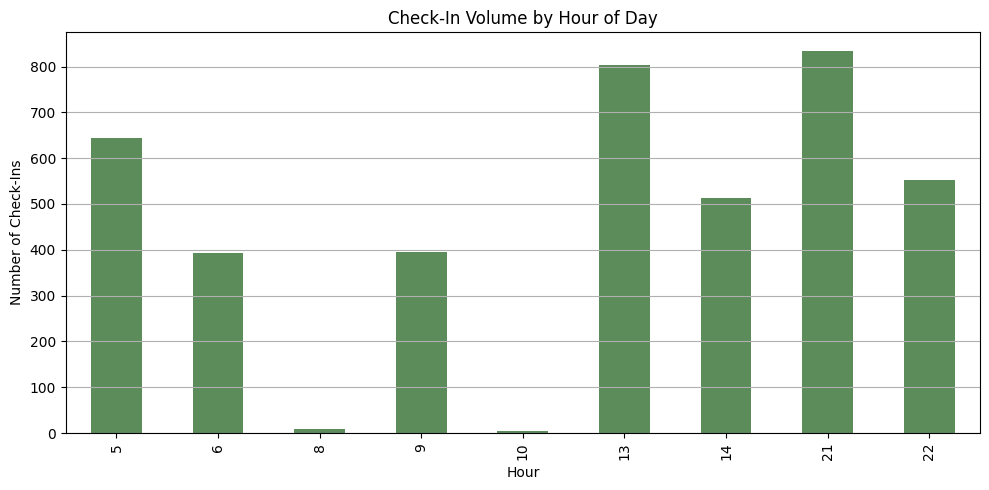

In [15]:
df['hour'] = df['timestamp'].dt.hour
checkin_hours = df[df['event_type']=='Check-In']['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
checkin_hours.plot(kind='bar', color='#5B8C5A')
plt.title("Check-In Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Check-Ins")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## 8. Employee ranking by attendance

In [16]:
total_working_days = attendance['date'].nunique()

ranking = attendance.groupby(['employee_id', 'department']).agg(
    Days_Present=('date', 'nunique'),
    Late_Count=('is_late', lambda x: (x == 'Yes').sum())
).reset_index()

ranking['Attendance_Rate (%)'] = (ranking['Days_Present'] / total_working_days * 100).round(2)
ranking['Days_Absent'] = total_working_days - ranking['Days_Present']
ranking['Rank'] = ranking['Attendance_Rate (%)'].rank(method='dense', ascending=False).astype(int)

threshold = 80
ranking['Warning'] = ranking['Attendance_Rate (%)'].apply(
    lambda x: "Below Threshold" if x < threshold else "Good"
)

ranking = ranking.sort_values('Rank')
ranking[['Rank','employee_id','department','Days_Present','Days_Absent',
         'Attendance_Rate (%)','Late_Count','Warning']].head(20)

,Rank,employee_id,department,Days_Present,Days_Absent,Attendance_Rate (%),Late_Count,Warning
51,1,E1052,Security,76,8,90.48,15,Good
10,2,E1011,Security,75,9,89.29,11,Good
12,3,E1013,Security,74,10,88.10,10,Good
41,4,E1042,Security,73,11,86.90,13,Good
18,5,E1019,Security,72,12,85.71,12,Good
47,5,E1048,Security,72,12,85.71,10,Good
24,6,E1025,Production,71,13,84.52,15,Good
1,6,E1002,Warehouse,71,13,84.52,12,Good
48,6,E1049,Production,71,13,84.52,14,Good
5,6,E1006,Production,71,13,84.52,6,Good
